In [1]:
import sys
from pathlib import Path
# Get project root (current working directory when running from project root)
# If running from research/, use parent; otherwise use cwd()
project_root = Path.cwd() if (Path.cwd() / 'vault').exists() else Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
from utils.enums import Ticker, TimeFrame, Direction
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from feature_extraction.feature_extractor import extract_features
from feature_selection.base_models import BaseModel, QuantileBinningModel
from ensemble.vault_manager import (
    initialize_vault, create_ensemble_directory, 
    load_feature_base_models, list_features
)
from eda.feature_explorer import FeatureExplorer
import utils.helpers as helpers

/home/raman/repos/Trading-Algo/utils/permutation_test/permute_bars.py:38: UserWarning: feature_selection.opt_thresh not found. Using simplified threshold optimization. For full functionality, ensure the opt_thresh module is available.
  warnings.warn(


# RSI Bias Node Test - Lookback = 2

This notebook demonstrates:
1. Extracting the RSI feature with lookback = 2
2. Visualizing the feature and comparing with returns
3. Creating a BaseModel with binning
4. Saving to vault as an end-to-end integration test

In [3]:
# Step 1: Load candles data for multiple tickers
# BaseModel will compute features internally from candles
# Use the new multi-ticker helper that appends rows with ticker column
# Define tickers for this ensemble (used throughout notebook)
ensemble_tickers = [Ticker.ES, Ticker.NQ, Ticker.YM, Ticker.RTY]

candles_df = helpers.load_data_multi_ticker(
    tickers=ensemble_tickers,
    timeframe=TimeFrame.D,
    start=datetime(2000, 1, 1),
    end=datetime(2024, 12, 31),
    use_millisecond_offset=True
)

print(f"Candles shape: {candles_df.shape}")
print(f"Candles columns: {list(candles_df.columns)}")
print(f"\nUnique tickers: {candles_df['ticker'].unique()}")
print(f"\nFirst few candles:")
print(candles_df.head())

# Compute targets from candles (for visualization and model fitting)
# 
# CRITICAL: Use forward returns to avoid lookahead bias!
# 
# The feature at timestamp t is computed from candle data at timestamp t (including close[t]).
# If we use the return from the same candle (close[t]/open[t]), that's lookahead bias because
# the feature computation might use close[t], and then we're predicting close[t]/open[t] from the same candle.
#
# Correct approach:
# - Feature at timestamp t: computed from data up to and including timestamp t
# - Target at timestamp t: forward return from t to t+1 = close[t+1] / close[t]
# - This means: feature[t] predicts return[t] (the return from t to t+1)
#
# This ensures that a prediction made at timestamp x is only used at timestamp x+1,
# avoiding any lookahead bias.

targets_list = []
for ticker in candles_df['ticker'].unique():
    ticker_candles = candles_df[candles_df['ticker'] == ticker].copy().sort_values('datetime')
    
    # Calculate forward returns: return at t = close[t+1] / close[t]
    # This represents the return from timestamp t to t+1
    ticker_candles['next_close'] = ticker_candles['close'].shift(-1)
    
    # Forward log return: log(close[t+1] / close[t])
    ticker_candles['log_return'] = np.log(ticker_candles['next_close'] / ticker_candles['close'])
    
    # Forward raw return: (close[t+1] / close[t]) - 1
    ticker_candles['raw_return'] = (ticker_candles['next_close'] / ticker_candles['close']) - 1
    
    # Drop last row (no forward return available - no t+1 for the last candle)
    ticker_candles = ticker_candles.dropna(subset=['log_return'])
    
    ticker_targets = pd.DataFrame({
        'datetime': ticker_candles['datetime'].values,
        'raw_return': ticker_candles['raw_return'].values,
        'log_return': ticker_candles['log_return'].values,
    })
    ticker_targets['ticker'] = ticker
    targets_list.append(ticker_targets)

targets = pd.concat(targets_list, axis=0, ignore_index=True)
print(f"\nTargets shape: {targets.shape}")
print(f"Targets columns: {list(targets.columns)}")
print(f"\n✓ Forward returns calculated correctly:")
print(f"  - Return at timestamp t = return from t to t+1")
print(f"  - Feature at timestamp t predicts return[t] (forward return)")
print(f"  - No lookahead bias: feature uses data up to t, predicts return from t to t+1")

Candles shape: (20298, 9)
Candles columns: ['timestamp', 'datetime', 'open', 'high', 'low', 'close', 'volume', 'ticker', 'timeframe']

Unique tickers: [<Ticker.ES: 'US500'> <Ticker.NQ: 'US100'> <Ticker.YM: 'US30'>
 <Ticker.RTY: 'RUSSELL_2000'>]

First few candles:
   timestamp                datetime    open     high      low   close  \
0  946857600 2000-01-03 00:00:00.000  1489.0  1496.00  1452.25  1466.8   
1  946857600 2000-01-03 00:00:00.001  3750.0  3895.00  3681.00  3844.5   
2  946944000 2000-01-04 00:00:00.000  1467.0  1468.75  1409.50  1411.8   
3  946944000 2000-01-04 00:00:00.001  3838.5  3842.50  3525.00  3557.5   
4  947030400 2000-01-05 00:00:00.000  1411.5  1427.25  1385.00  1413.5   

   volume     ticker    timeframe  
0   61938  Ticker.ES  TimeFrame.D  
1   15414  Ticker.NQ  TimeFrame.D  
2   64048  Ticker.ES  TimeFrame.D  
3   15455  Ticker.NQ  TimeFrame.D  
4   73121  Ticker.ES  TimeFrame.D  

Targets shape: (20294, 4)
Targets columns: ['datetime', 'raw_return', 'lo

In [4]:
# Step 2: Create BaseModel (will compute features internally from candles)
# BaseModel owns bias nodes via composition - no need to pre-extract features!
binning_model = QuantileBinningModel(n_bins=10, selection_metric='sortino', strategy='long')

bias_spec = {
    'module_name': 'rsi',
    'timeframes': [TimeFrame.D],
    'params': {'lookback': 2}
}

# Create BaseModel for multiple tickers (training in aggregate)
# BaseModel will create bias nodes internally based on bias_node_spec
base_model = BaseModel(
    feature_config={'bias_node_spec': bias_spec},
    binning_model=binning_model,
    tickers=ensemble_tickers
)

print("BaseModel created successfully!")
print(f"  Ticker: {base_model.ticker.name}")
print(f"  Bias node spec: {base_model.bias_node_spec}")
print(f"  Number of bias nodes: {len(base_model.bias_nodes)}")
print(f"  Timeframes: {list(base_model.bias_nodes.keys())}")

# Note: Features will be computed internally when we call fit() or add_candle()
# This demonstrates the key design: BaseModel owns bias nodes and computes features from candles

BaseModel created successfully!
  Ticker: ES
  Bias node spec: {'module_name': 'rsi', 'timeframes': [<TimeFrame.D: 86400>], 'params': {'lookback': 2}}
  Number of bias nodes: 4
  Timeframes: [(<Ticker.ES: 'US500'>, <TimeFrame.D: 86400>), (<Ticker.NQ: 'US100'>, <TimeFrame.D: 86400>), (<Ticker.YM: 'US30'>, <TimeFrame.D: 86400>), (<Ticker.RTY: 'RUSSELL_2000'>, <TimeFrame.D: 86400>)]


In [5]:
# Step 3: Extract features using BaseModel (for experimentation)
# We extract features once, then experiment with different binning models
# BaseModel is only needed when saving to vault

# IMPORTANT: Filter candles to only those with forward returns
# Forward returns are calculated as: return[t] = close[t+1] / close[t]
# So the last candle doesn't have a forward return
# We need to filter candles to match available targets

# Get datetimes that have forward returns (targets)
target_datetimes = pd.DatetimeIndex(targets['datetime'].unique())
print(f"Targets have {len(target_datetimes)} datetimes (forward returns)")

# Filter candles to only those with forward returns
all_candles = candles_df[candles_df['datetime'].isin(target_datetimes)].copy()
print(f"Filtered candles to {len(all_candles)} rows (matching forward returns)")

# Prepare target data aligned with candles (for all tickers)
# Targets are forward returns: return[t] = return from t to t+1
all_targets = targets.copy()
target_series = pd.Series(
    all_targets['log_return'].values,
    index=pd.DatetimeIndex(all_targets['datetime']),
    name='log_return'
)

# Reset candles index to use integer index (BaseModel.fit expects this)
all_candles_fit = all_candles.reset_index(drop=True)

# Extract features using BaseModel (this fits the bias nodes and extracts features)
# We'll fit a binning model just to get the features extracted
print("Extracting features...")
print(f"  Candles: {len(all_candles_fit)} rows")
print(f"  Targets: {len(target_series)} rows")
print(f"  Tickers: {[t.name for t in ensemble_tickers]}")

# Fit BaseModel to extract features (we'll ignore the binning model for now)
base_model.fit(all_candles_fit, target_series)

# Extract features for experimentation
feature_series = base_model.get_feature()
print(f"\n✓ Features extracted successfully!")
print(f"  Feature column: {base_model.feature_column}")
print(f"  Feature statistics:")
print(f"    Min: {feature_series.min():.4f}")
print(f"    Max: {feature_series.max():.4f}")
print(f"    Mean: {feature_series.mean():.4f}")
print(f"    Std: {feature_series.std():.4f}")
print(f"    Unique values: {feature_series.nunique()}")

# Create features DataFrame for FeatureExplorer (for visualization)
features = pd.DataFrame({base_model.feature_column: feature_series})
# Add ticker column from original candles (for visualization)
features['ticker'] = all_candles.set_index('datetime').reindex(feature_series.index)['ticker'].values

# Build metadata for FeatureExplorer
metadata = {'feature_metadata': {}}
parsed = helpers.parse_feature_column_name(base_model.feature_column)
metadata['feature_metadata'][base_model.feature_column] = {
    'module': parsed.get('module'),
    'parameters': parsed.get('params', {}),
    'timeframes': [parsed.get('tf')] if parsed.get('tf') else [],
    'base_name': parsed.get('module'),
    'full_name': base_model.feature_column
}

# Create FeatureExplorer for visualization
# Use all targets and set datetime as index
all_targets_indexed = targets.set_index('datetime')
# Align targets with feature series index (datetime index from BaseModel)
all_targets_aligned = all_targets_indexed.reindex(feature_series.index)

explorer = FeatureExplorer(
    features_df=features.set_index(feature_series.index),
    targets_df=all_targets_aligned,
    metadata=metadata
)

print("\nFeatureExplorer created successfully!")
print(f"  Number of features: {explorer.n_features}")
print(f"  Feature names: {explorer.feature_names}")
print(f"  Number of samples: {explorer.n_samples}")

Targets have 20294 datetimes (forward returns)
Filtered candles to 20294 rows (matching forward returns)
Extracting features...
  Candles: 20294 rows
  Targets: 20294 rows
  Tickers: ['ES', 'NQ', 'YM', 'RTY']

✓ Features extracted successfully!
  Feature column: rsi_signal_D_lookback_2
  Feature statistics:
    Min: 0.0352
    Max: 100.0000
    Mean: 55.3585
    Std: 31.5941
    Unique values: 20118

FeatureExplorer created successfully!
  Number of features: 1
  Feature names: ['rsi_signal_D_lookback_2']
  Number of samples: 20294


Plotting decile analysis...


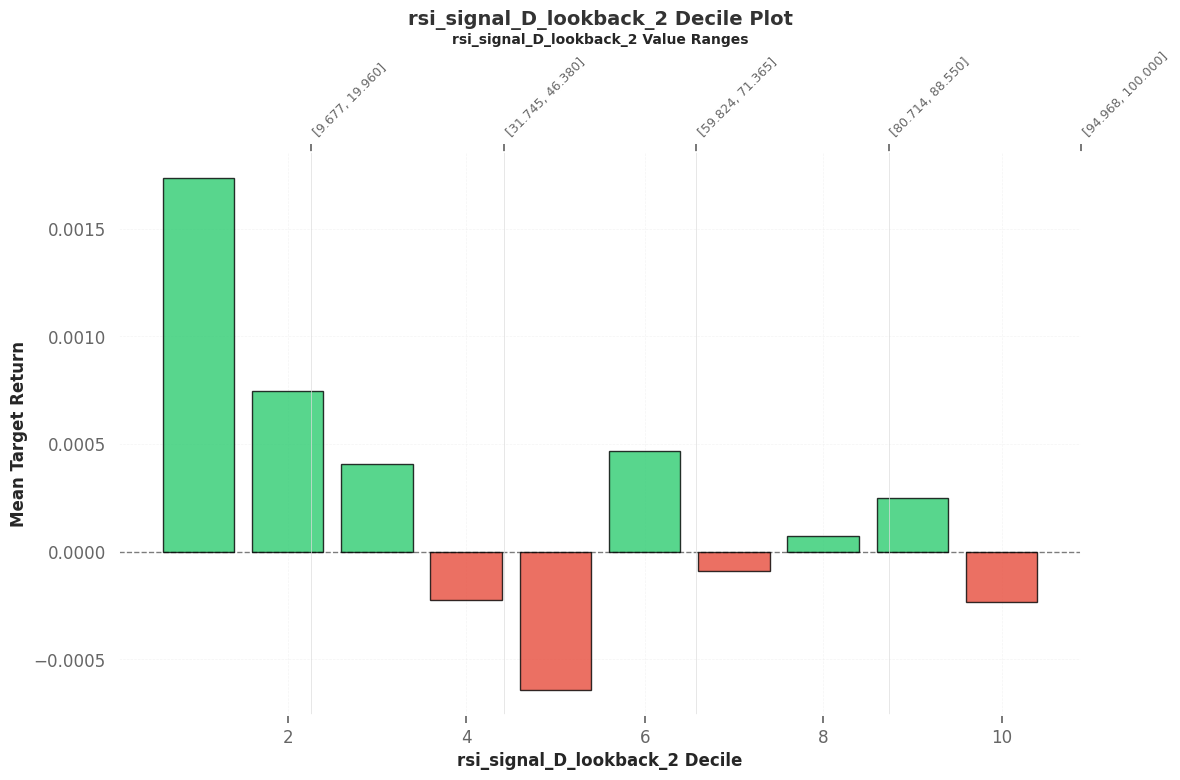


Plotting 2-bin analysis...


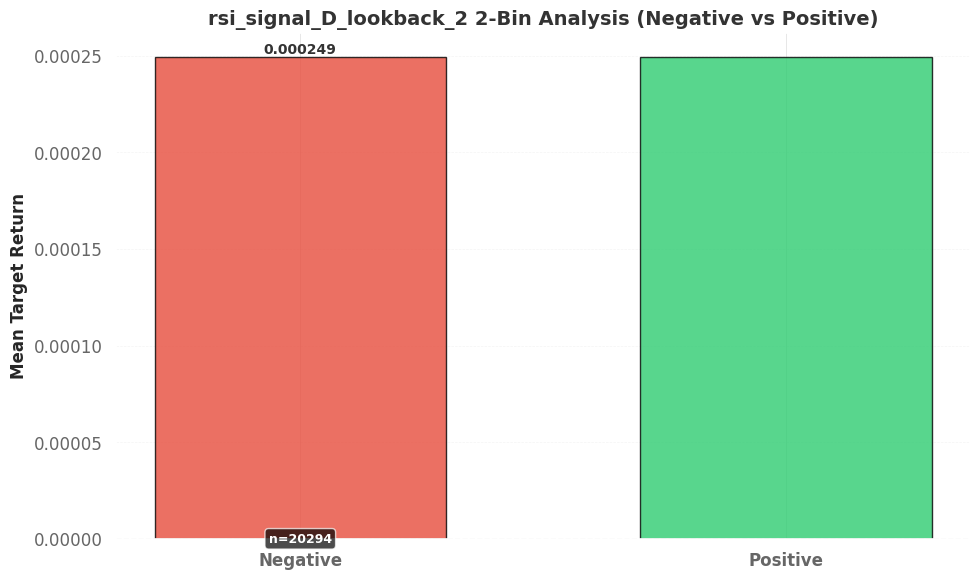

In [6]:
# Step 4: Analyze feature with decile plots
# Decile analysis shows how feature values relate to returns
# This helps understand the feature before looking at trading signals

print("Plotting decile analysis...")
decile_fig = explorer.plot_deciles(
    feature_name=base_model.feature_column,
    n_bins=10,
    target_col='log_return',
    figsize=(12, 8)
)
plt.show()

# Also show 2-bin analysis (similar to our binning model)
print("\nPlotting 2-bin analysis...")
bin2_fig = explorer.plot_2bin(
    feature_name=base_model.feature_column,
    target_col='log_return',
    figsize=(10, 6)
)
plt.show()

Binning model fitted:
  Best long bin: 0
  Thresholds: [ 9.67544809 19.96014805 31.72804768 46.37961719 59.82077021 71.36471564
 80.71188161 88.55047868 94.96792101]

Plotting signal-gated cumulative returns for 1 features
Target: log_return | Strategy: long

[1/1] rsi_signal_D_lookback_2
  ✓ Complete


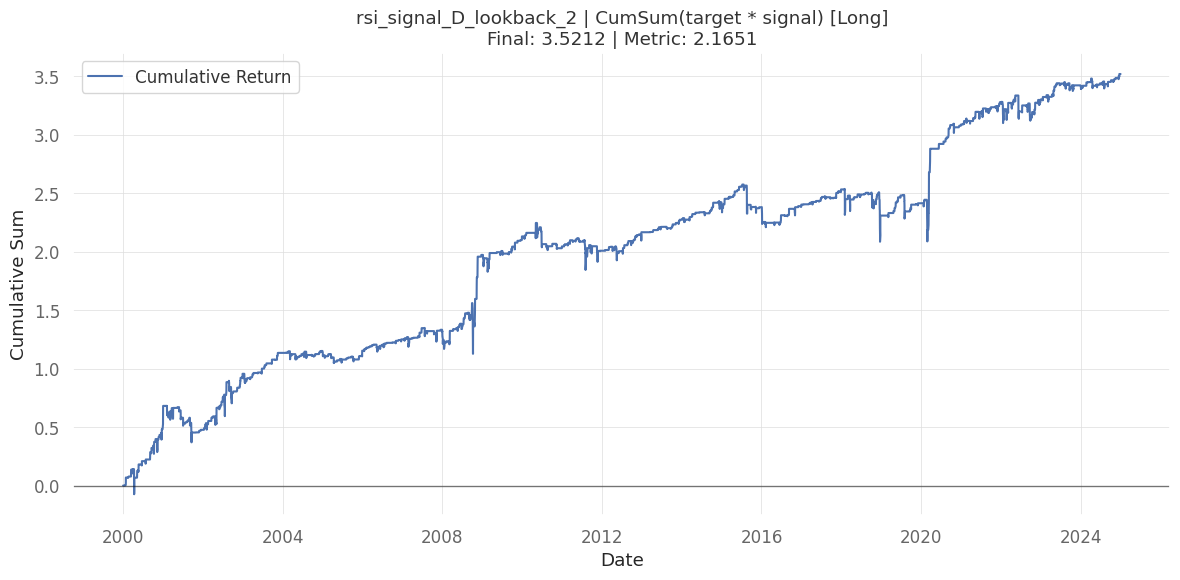


Signal Performance Summary:
                   feature  n_samples  n_signals  final_cumsum    metric
0  rsi_signal_D_lookback_2      20294       2029      3.521217  2.165128


In [7]:
# Step 5: Fit binning model and visualize signal performance
# Now that we understand the feature distribution, fit a binning model and see trading signals
from metrics.performance import SortinoRatio
metric = SortinoRatio(annualization_factor=252)

# Fit binning model on extracted features
base_model.binning_model.fit(feature_series, target_series.reindex(feature_series.index))

print(f"Binning model fitted:")
print(f"  Best long bin: {base_model.binning_model.best_long_bin_}")
print(f"  Thresholds: {base_model.binning_model.thresholds_}")

# Visualize signal performance with FeatureExplorer
figs, summary = explorer.plot_signal_cumsum(
    target_col='log_return',
    base_model=base_model,
    show_plot=True,
    metric=metric,
    strategy='long'
)
plt.show()

print("\nSignal Performance Summary:")
print(summary)

# Experimentation Cells

Use the cells below to experiment with different binning model configurations. 

**Workflow:**
1. Features are already extracted in Step 3
2. Step 4 shows decile analysis to understand feature distribution
3. Step 5 fits initial binning model and shows signal performance
4. Experiment cells below: try different binning models on extracted features
5. BaseModel is only needed when saving to vault (see Step 6+)

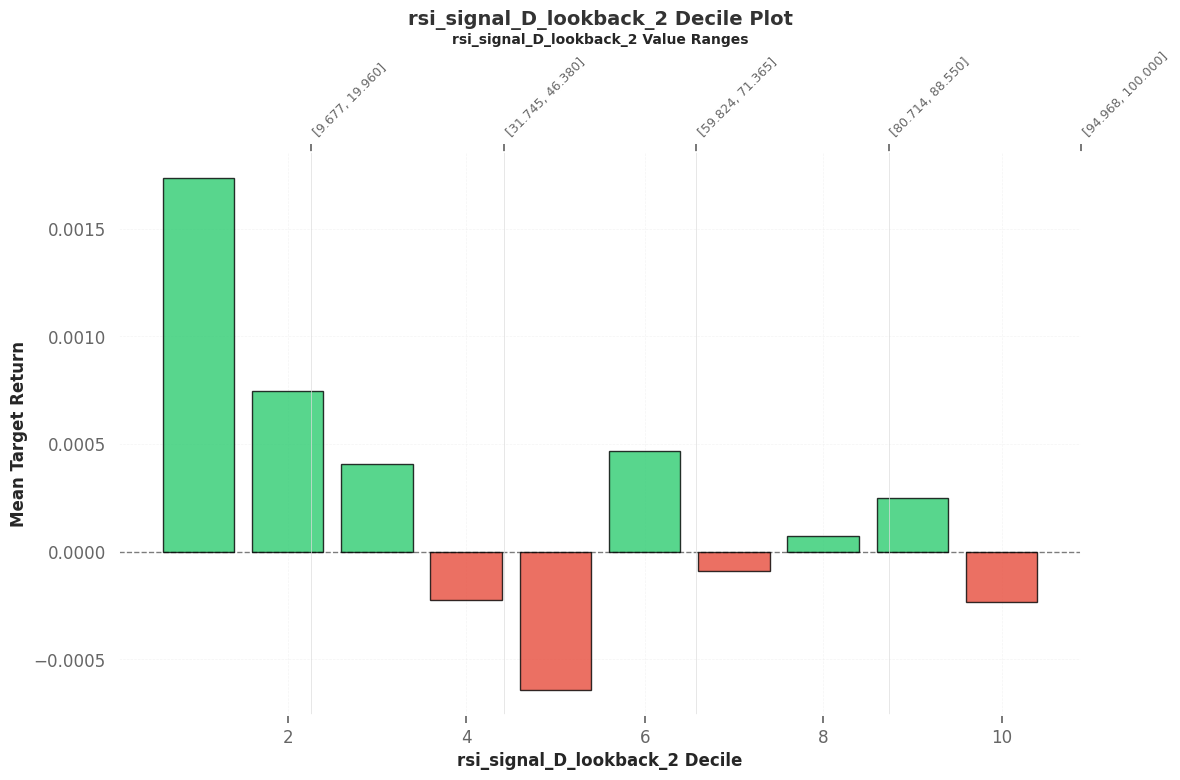

In [8]:
# Experiment 3: View decile analysis
# See how feature values relate to returns across deciles

explorer.plot_deciles(
    feature_name=base_model.feature_column,
    n_bins=10,
    target_col='log_return'
)
plt.show()

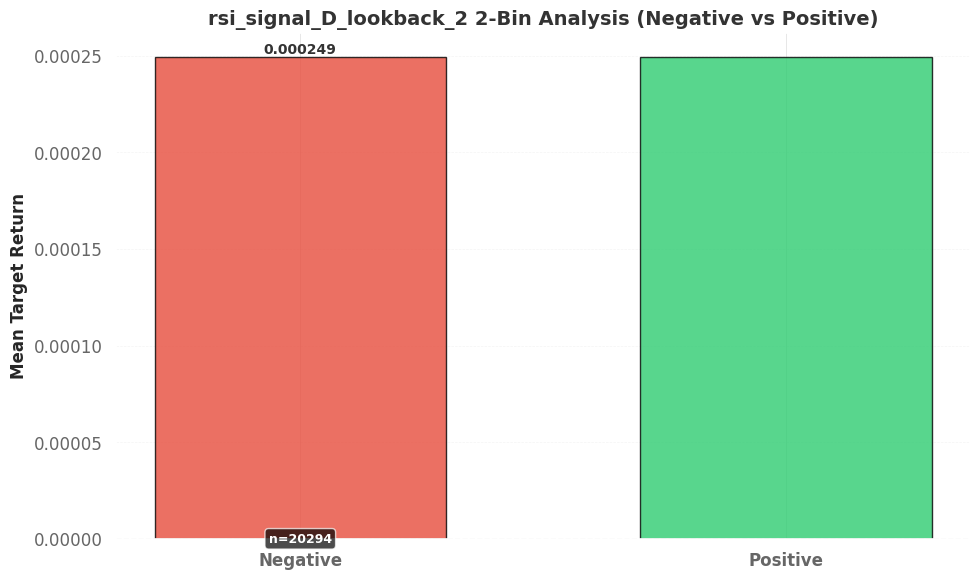

In [9]:
# Experiment 4: View 2-bin analysis
# Compare positive vs negative feature values

explorer.plot_2bin(
    feature_name=base_model.feature_column,
    target_col='log_return'
)
plt.show()

In [10]:
# Step 5: Test predictions
# BaseModel.predict() now supports multiple tickers
# Test with all tickers (last 100 candles across all tickers)
test_candles = candles_df.tail(100).copy()  # Last 100 candles
predictions = base_model.predict(test_candles, strategy='long')

print(f"Predictions shape: {predictions.shape}")
print(f"Unique prediction values: {np.unique(predictions)}")
print(f"\nFirst 10 predictions:")
print(predictions.head(10))

Predictions shape: (100,)
Unique prediction values: [0 1]

First 10 predictions:
2024-11-25    0
2024-11-26    0
2024-11-27    0
2024-11-29    0
2024-12-02    0
2024-12-03    0
2024-12-04    0
2024-12-05    0
2024-12-06    0
2024-12-09    0
dtype: int64


In [11]:
# Experiment 6: Try different RSI lookback values
# To test different RSI periods, you need to re-extract features
# Uncomment and modify, then re-run Step 3:

# bias_spec = {
#     'module_name': 'rsi',
#     'timeframes': [TimeFrame.D],
#     'params': {'lookback': 5}  # Try: 2, 5, 14, 21
# }
# 
# Then create new BaseModel and extract features:
# new_base_model = BaseModel(
#     feature_config={'bias_node_spec': bias_spec},
#     binning_model=QuantileBinningModel(n_bins=2, selection_metric='sortino', strategy='long'),
#     tickers=ensemble_tickers
# )
# new_base_model.fit(all_candles_fit, target_series)
# new_feature_series = new_base_model.get_feature()
# 
# Then experiment with binning models on new_feature_series

In [12]:


print("Creating ensemble directory...")
# ensemble_tickers is defined in Step 1 - must match the tickers used in data
ensemble_dir = create_ensemble_directory(
    timeframe=TimeFrame.D,
    ensemble_name='rsi_bias_lookback_2',
    direction=Direction.LONG,
    tickers=ensemble_tickers
)

print(f"✓ Created ensemble directory: {ensemble_dir}")
print(f"  Ensemble tickers: {[t.name for t in ensemble_tickers]}")
print(f"  Default ensemble directory is now set automatically")

Creating ensemble directory...
✓ Created ensemble directory: /home/raman/repos/Trading-Algo/vault/D/rsi_bias_lookback_2_long
  Ensemble tickers: ['ES', 'NQ', 'YM', 'RTY']
  Default ensemble directory is now set automatically


In [13]:

print("\nSaving base model to vault...")
# Pass all ensemble tickers when saving (even though BaseModel was created for ES)
# This ensures the feature spec stores all tickers the ensemble uses
# ensemble_dir is optional - uses default set by create_ensemble_directory()
model_id = base_model.save_to_vault(tickers=ensemble_tickers)
print(f"✓ Saved model with ID: {model_id}")
print(f"  Feature column: {base_model.feature_column}")
print(f"  Model ID: {model_id}")
print(f"  Saved with tickers: {[t.name for t in ensemble_tickers]}")


Saving base model to vault...
✓ Saved model with ID: quantile_binning_10
  Feature column: rsi_signal_D_lookback_2
  Model ID: quantile_binning_10
  Saved with tickers: ['ES', 'NQ', 'YM', 'RTY']


In [14]:
# Step 8: Verify vault save/load
print("Loading models from vault...")
# ensemble_dir is optional - uses default set by create_ensemble_directory()
# Path resolution automatically handles running from research/ directory
loaded_models = load_feature_base_models(feature_column=base_model.feature_column)
model_id = 'quantile_binning_2'

print(f"✓ Loaded {len(loaded_models)} model(s)")
print(f"  Model keys (ticker, model_id): {list(loaded_models.keys())}")

# Verify loaded model (keys are now (ticker, model_id) tuples)
key = (Ticker.ES, model_id)
if key in loaded_models:
    loaded_model = loaded_models[key]
    print(f"\n✓ Model '{model_id}' for {Ticker.ES.name} loaded successfully")
    print(f"  Binning model fitted: {loaded_model.binning_model.is_fitted_}")
    print(f"  Best long bin: {loaded_model.binning_model.best_long_bin_}")
    print(f"  Ticker: {loaded_model.ticker.name}")
    
    # Test predictions with loaded model
    test_predictions = loaded_model.predict(test_candles, strategy='long')
    print(f"  Predictions from loaded model shape: {test_predictions.shape}")
    print(f"  Unique predictions: {np.unique(test_predictions)}")
else:
    print(f"\n✗ Model '{model_id}' not found. Available keys: {list(loaded_models.keys())}")

# List all features in ensemble
print("\n" + "="*70)
print("Features in ensemble:")
print("="*70)
# ensemble_dir is optional - uses default set by create_ensemble_directory()
features_df = list_features()
print(features_df)

Loading models from vault...
✓ Loaded 4 model(s)
  Model keys (ticker, model_id): [(<Ticker.ES: 'US500'>, 'quantile_binning_10'), (<Ticker.NQ: 'US100'>, 'quantile_binning_10'), (<Ticker.RTY: 'RUSSELL_2000'>, 'quantile_binning_10'), (<Ticker.YM: 'US30'>, 'quantile_binning_10')]

✗ Model 'quantile_binning_2' not found. Available keys: [(<Ticker.ES: 'US500'>, 'quantile_binning_10'), (<Ticker.NQ: 'US100'>, 'quantile_binning_10'), (<Ticker.RTY: 'RUSSELL_2000'>, 'quantile_binning_10'), (<Ticker.YM: 'US30'>, 'quantile_binning_10')]

Features in ensemble:
              feature_name           feature_column  n_base_models  n_fitted  \
0  rsi_signal_D_lookback_2  rsi_signal_D_lookback_2              1         1   

                         created_at                        updated_at  
0  2026-01-23T05:39:22.532988+00:00  2026-01-23T05:39:22.533006+00:00  
